**AUTOREGRESSION MODEL**

In [2]:
import pandas as pd
df = pd.read_csv('daily-min-temperatures.csv', header=0, parse_dates=[0])
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [10]:
train, test = df.Temp[0:df.shape[0]-5] , df.Temp[df.shape[0]-5:]
train.head()

0    20.7
1    17.9
2    18.8
3    14.6
4    15.8
Name: Temp, dtype: float64

In [49]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(train, lags=29)
model_fit = model.fit()

In [51]:
model_fit.params

const       0.558634
Temp.L1     0.588501
Temp.L2    -0.090898
Temp.L3     0.048259
Temp.L4     0.039889
Temp.L5     0.039423
Temp.L6     0.025969
Temp.L7     0.044811
Temp.L8     0.013270
Temp.L9     0.037082
Temp.L10   -0.000620
Temp.L11    0.004940
Temp.L12    0.017855
Temp.L13    0.026953
Temp.L14    0.000615
Temp.L15    0.024226
Temp.L16    0.007317
Temp.L17    0.009932
Temp.L18    0.034503
Temp.L19   -0.008847
Temp.L20    0.024436
Temp.L21    0.018736
Temp.L22    0.012400
Temp.L23   -0.018518
Temp.L24   -0.001771
Temp.L25    0.016640
Temp.L26    0.019895
Temp.L27    0.009820
Temp.L28    0.006167
Temp.L29   -0.001725
dtype: float64

In [52]:
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)
predictions

3645    14.351454
3646    13.637617
3647    13.365484
3648    13.411983
3649    13.445439
dtype: float64

In [27]:
df.tail()

,Date,Temp
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7
3649,1990-12-31,13.0


In [53]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test, predictions)
mse

1.1152934751683485

- here we see that using AR model the MSE is reduced which implies the TS-Data is not a random walk

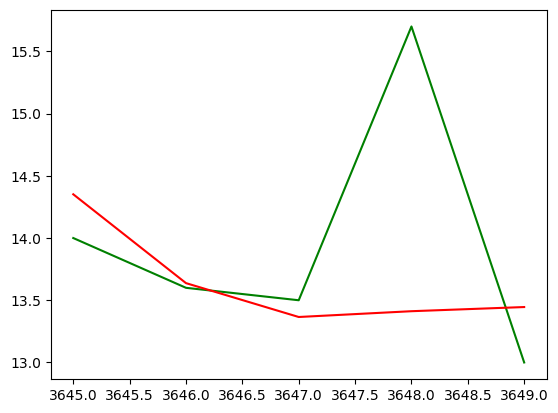

In [54]:
from matplotlib import pyplot
pyplot.plot(test, color='green')
pyplot.plot(predictions, color='red')